# SPI--SPI recovery of dynamical order parameters

This notebook is the paper-facing comparison. It asks whether the same target-blind SPI--SPI construction produces a coordinate $q$ that follows an independently defined physical order parameter $Q$ as a control parameter crosses a dynamical transition.

The systems are not presented as equally strong:

1. **Stuart--Landau:** published collective-oscillator phase diagram, the main $M\times T$ robustness benchmark, and a clean independent fine-boundary confirmation.
2. **Miller--Huse:** canonical nonequilibrium symmetry-breaking benchmark.
3. **Kuramoto:** canonical but comparatively easy synchronization baseline; the available full-catalogue result is retrospective.
4. **Quadratic CML:** noncanonical regime-coordinate stress test and useful negative result.

The detailed system notebooks remain the provenance and diagnostic records, including representative trajectories/fields and robust per-process `icefire` MTS heatmaps: [Kuramoto](kuramoto-order-parameter-confirmation.ipynb), [Stuart--Landau](stuart-landau-order-coordinate.ipynb), [Miller--Huse](miller-huse-order-coordinate.ipynb), and [quadratic CML](quadratic-cml-order-coordinate.ipynb).

## Representation and claim vocabulary

For an $M\times T$ multivariate time series $X$, each SPI $a\in\{1,\ldots,K\}$ produces an $M\times M$ matrix of pairwise channel statistics. Let $v_a$ be its vector of channel-pair entries. The second-order meta-feature is

\[
z_{ab}=\operatorname{corr}(v_a,v_b),\qquad 1\leq a<b\leq K.
\]

With all $K=289$ p90 SPIs, $z\in\mathbb R^{41{,}616}$. Development-only validity filtering, median imputation, centring/scaling and PCA are fitted without controls or physical targets. The frozen first component is $q$; its sign is mathematically arbitrary and is flipped only for readable display when necessary.

The claims are deliberately distinct:

- **Tracking/recovery:** frozen target-blind $q$ changes monotonically with held-out $Q$. This is assessed primarily by Spearman correlation.
- **Macroscopic curve recovery:** correlation between means of $q$ and $Q$ across realizations at each fixed control value. This asks whether the transition curve is recovered after averaging run variability.
- **Within-control recovery:** association between $q$ and $Q$ after removing their mean at each fixed control value. This asks whether $q$ captures run-to-run physical fluctuations, not merely the sweep.
- **Numerical inference/prediction:** a separately supervised decoder $q\mapsto\widehat Q$, assessed by held-out MAE.
- **Transition localization:** a target-free peak or change in $q$'s variance/susceptibility near a known boundary. This is supplementary.

Shaded bands below are nonparametric 95% bootstrap intervals for the **mean across independent runs within each control cell**. They quantify uncertainty in the plotted mean, not the full variability of a single run.

In [1]:
from pathlib import Path
import json
import shutil
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "src").exists():
    ROOT = ROOT.parent
FIGURE_DIR = ROOT / "notebooks/inference/figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

USE_TEX = shutil.which("latex") is not None and shutil.which("dvipng") is not None
mpl.rcParams.update({
    "text.usetex": USE_TEX,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 10,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.grid": False,
    "figure.dpi": 180,
    "savefig.dpi": 600,
    "savefig.bbox": "tight",
})
if not USE_TEX:
    print("LaTeX executables are unavailable to this kernel; using Computer Modern mathtext.")

COLORS = {8: "#440154", 16: "#31688e", 20: "#26828e", 32: "#35b779"}
Q_COLOR = "#222222"
Q_FILL = "#777777"
CONTROL_LABELS = {
    "kappa": r"reduced coupling $\kappa$",
    "gamma": r"frequency half-width $\gamma$",
    "g": r"coupling $g$",
    "alpha": r"map nonlinearity $\alpha$",
}

def paper_axis(ax, *, right=False):
    # Standard unboxed paper axis; keep the active y-side visible.
    ax.grid(False)
    ax.spines["top"].set_visible(False)
    if right:
        ax.spines["left"].set_visible(False)
        ax.spines["right"].set_visible(True)
        ax.yaxis.set_ticks_position("right")
        ax.yaxis.set_label_position("right")
        ax.tick_params(direction="out", top=False, left=False, right=True)
    else:
        ax.spines["right"].set_visible(False)
        ax.tick_params(direction="out", top=False, right=False)
    # For a boxed look, comment out the spine-hiding calls above.

def bootstrap_curve(frame, control, value, *, bootstraps=2000, seed=1701):
    rows = []
    for offset, (level, group) in enumerate(frame.groupby(control, sort=True)):
        values = group[value].to_numpy(dtype=float)
        values = values[np.isfinite(values)]
        rng = np.random.default_rng(seed + offset)
        samples = values[rng.integers(0, len(values), size=(bootstraps, len(values)))]
        boot_means = samples.mean(axis=1)
        rows.append((level, values.mean(), *np.quantile(boot_means, [.025, .975])))
    return pd.DataFrame(rows, columns=[control, "mean", "lower", "upper"])

def dual_tracking(ax, frame, *, control, Q, q, q_sign=1.0, q_color="#2b6cb0", boundary=None, title="", Q_label=r"physical $Q$"):
    q_axis = ax.twinx()
    physical = bootstrap_curve(frame, control, Q, seed=2711)
    learned = bootstrap_curve(frame, control, q, seed=3613)
    learned[["mean", "lower", "upper"]] *= q_sign
    if q_sign < 0:
        learned[["lower", "upper"]] = learned[["upper", "lower"]].to_numpy()

    line_Q, = ax.plot(physical[control], physical["mean"], color=Q_COLOR, lw=1.8, marker="o", ms=2.8, label=Q_label)
    ax.fill_between(physical[control], physical["lower"], physical["upper"], color=Q_FILL, alpha=.16, linewidth=0)
    line_q, = q_axis.plot(learned[control], learned["mean"], color=q_color, lw=1.7, marker="s", ms=2.6, label=r"frozen $q$")
    q_axis.fill_between(learned[control], learned["lower"], learned["upper"], color=q_color, alpha=.16, linewidth=0)
    if boundary is not None:
        ax.axvline(boundary, color="#666666", lw=.9, ls=":")
    ax.set_xlabel(CONTROL_LABELS.get(control, control))
    ax.set_ylabel(r"physical $Q$", color=Q_COLOR)
    q_axis.set_ylabel(r"frozen $q$", color=q_color)
    ax.tick_params(axis="y", colors=Q_COLOR)
    q_axis.tick_params(axis="y", colors=q_color)
    ax.set_title(title)
    paper_axis(ax)
    paper_axis(q_axis, right=True)
    ax.legend([line_Q, line_q], [line_Q.get_label(), line_q.get_label()], frameon=False, loc="best")
    return q_axis

def recovery_scatter(ax, frame, *, Q, q, control, q_sign=1.0, title=""):
    q_values = q_sign * frame[q].to_numpy(dtype=float)
    points = ax.scatter(q_values, frame[Q], c=frame[control], cmap="viridis", s=15, alpha=.45, edgecolors="none")
    means = frame.assign(_q=q_values).groupby(control)[["_q", Q]].mean().sort_index()
    ax.plot(means["_q"], means[Q], color="#b2182b", lw=1.2, marker="o", ms=2.8, label="mean across realizations at fixed control")
    ax.set_xlabel(r"frozen $q$")
    ax.set_ylabel(r"physical $Q$")
    ax.set_title(title)
    ax.legend(frameon=False)
    paper_axis(ax)
    return points

def size_tracking(frame, *, control, Q, q, q_sign, boundary, title):
    sizes = sorted(frame["M"].unique())
    fig, axes = plt.subplots(1, len(sizes), figsize=(3.75 * len(sizes), 3.15), constrained_layout=True)
    axes = np.atleast_1d(axes)
    for ax, M in zip(axes, sizes, strict=True):
        dual_tracking(
            ax,
            frame.query("M == @M"),
            control=control,
            Q=Q,
            q=q,
            q_sign=q_sign,
            q_color=COLORS[int(M)],
            boundary=boundary,
            title=rf"$M={int(M)}$",
        )
    fig.suptitle(title)
    return fig

def spearman(x, y):
    return pd.Series(x).corr(pd.Series(y), method="spearman")

KURAMOTO_ROOT = ROOT / "data/order_parameter/kuramoto_full_catalogue_reanalysis"
SL_ROOT = ROOT / "data/order_parameter/stuart_landau_confirmation_analysis"
SL_FINE_ROOT = ROOT / "data/order_parameter/stuart_landau_locking_boundary_confirmation_analysis"
MH_ROOT = ROOT / "data/order_parameter/miller_huse_confirmation_analysis"
CML_ROOT = ROOT / "data/order_parameter/quadratic_cml_development_analysis"

kuramoto_summary = json.loads((KURAMOTO_ROOT / "summary.json").read_text())
with np.load(KURAMOTO_ROOT / "results.npz", allow_pickle=True) as archive:
    primary = archive["primary_row_indices"]
    kuramoto = pd.DataFrame({
        "kappa": archive["kappa"][primary],
        "instance": archive["instance"][primary],
        "q": archive["coordinate_pc1"][primary],
        "Q": archive["target_full_future_R"][primary],
    })
kuramoto["M"] = 20

sl_summary = json.loads((SL_ROOT / "summary.json").read_text())
sl = pd.read_csv(SL_ROOT / "scores.csv")
sl_primary = sl.query("T == 1000").copy()
sl_fine_eligibility = json.loads((SL_FINE_ROOT / "eligibility_pre_outcome.json").read_text())
sl_fine_summary = json.loads((SL_FINE_ROOT / "summary.json").read_text())
sl_fine = pd.read_csv(SL_FINE_ROOT / "scores.csv")
assert sl_fine_eligibility["status"] == "eligible"
with np.load(ROOT / "data/order_parameter/stuart_landau_phase_plane/physics_records.npz") as archive:
    sl_plane = {key: archive[key] for key in archive.files}
sl_plane_summary = json.loads((ROOT / "data/order_parameter/stuart_landau_phase_plane/physics_summary.json").read_text())

mh_summary = json.loads((MH_ROOT / "summary.json").read_text())
mh = pd.read_csv(MH_ROOT / "scores.csv")

cml_summary = json.loads((CML_ROOT / "summary.json").read_text())
cml = pd.read_csv(CML_ROOT / "scores.csv")
cml_held = cml.query("arm == 'large' and instance >= 4").copy()

print("Loaded:", {"Kuramoto": len(kuramoto), "Stuart--Landau": len(sl), "Stuart--Landau fine boundary": len(sl_fine), "Miller--Huse": len(mh), "quadratic CML held": len(cml_held)})

Loaded: {'Kuramoto': 512, 'Stuart--Landau': 648, 'Stuart--Landau fine boundary': 152, 'Miller--Huse': 215, 'quadratic CML held': 492}


## Observation contracts: do any experiments have $M=N$?

Yes. Stuart--Landau's primary confirmation arm has $M=N\in\{8,16,32\}$. Quadratic CML also includes small $M=N\in\{8,16,32\}$ finite-size sensitivities, but they are not substitutes for the physically adequate $N=512$ lattice. Kuramoto and Miller--Huse recover hidden global quantities from partial observations.

In [2]:
display(pd.DataFrame([
    {"system": "Kuramoto", "physical N": 256, "observed M": "20", "M=N?": "No", "role": "partial-observation retrospective baseline"},
    {"system": "Stuart--Landau", "physical N": "8, 16, 32", "observed M": "8, 16, 32", "M=N?": "Yes", "role": "primary full-observation confirmation"},
    {"system": "Stuart--Landau (secondary)", "physical N": 800, "observed M": "8, 16, 32", "M=N?": "No", "role": "information-limited sensitivity; joint gate failed"},
    {"system": "Miller--Huse", "physical N": r"$128^2=16{,}384$", "observed M": "8, 16, 32", "M=N?": "No", "role": "physically adequate lattice with dispersed sensors"},
    {"system": "Quadratic CML", "physical N": 512, "observed M": "8, 16, 32", "M=N?": "No", "role": "primary stress-test arm"},
    {"system": "Quadratic CML (sensitivity)", "physical N": "8, 16, 32", "observed M": "8, 16, 32", "M=N?": "Yes", "role": "finite-size diagnostic only"},
]))

,system,physical N,observed M,M=N?,role
0,Kuramoto,256,20,No,partial-observation retrospective baseline
1,Stuart--Landau,"8, 16, 32","8, 16, 32",Yes,primary full-observation confirmation
2,Stuart--Landau (secondary),800,"8, 16, 32",No,information-limited sensitivity; joint gate fa...
3,Miller--Huse,"$128^2=16{,}384$","8, 16, 32",No,physically adequate lattice with dispersed sen...
4,Quadratic CML,512,"8, 16, 32",No,primary stress-test arm
5,Quadratic CML (sensitivity),"8, 16, 32","8, 16, 32",Yes,finite-size diagnostic only


# 1. Kuramoto synchronization baseline

### Governing equation

\[
\dot\theta_i=\omega_i+\frac{K}{N}\sum_{j=1}^{N}\sin(\theta_j-\theta_i),
\qquad
R(t)e^{i\Psi(t)}=\frac1N\sum_{j=1}^{N}e^{i\theta_j(t)}.
\]

The canonical order parameter is $Q=\overline{R_N}$, the future-time mean magnitude of the global phase-coherence vector. $R\approx0$ indicates incoherence and $R\approx1$ strong phase alignment. For a symmetric unimodal continuum frequency density, synchronization begins at $K_c=2/[\pi g(0)]$; this notebook uses reduced coupling $\kappa=K/K_c$, so the theoretical junction is $\kappa=1$.

**Control and phase structure.** The experiment sweeps $\kappa=0.625$ to $1.65$ across the continuous synchronization onset. This is a one-dimensional phase-transition curve rather than a two-control phase plane. Sources: [Kuramoto's original monograph](https://doi.org/10.1007/978-3-642-69689-3) and a verified treatment of order-parameter scaling at synchronization onset ([Xu, Wang & Skardal 2020](https://doi.org/10.1103/PhysRevE.102.042310)).

**Observation and $q$.** $N=256$, $M=20$, $T=1000$. The frozen full-289-SPI PC1 is displayed with its sign reversed so that increasing $q$ corresponds to increasing $Q$. This result is retrospective: the target was known before the final audit, although the representation fit itself used neither $\kappa$ nor $Q$.

**Performance.** Overall $|\rho|=0.956$, within-$\kappa$ $|\rho|=0.628$, and supervised isotonic MAE $=0.0589$. Mean absolute input correlation is stronger ($\rho=0.975$). Target-free variance of $q$ peaks at $\kappa=0.9925$, close to the known onset.

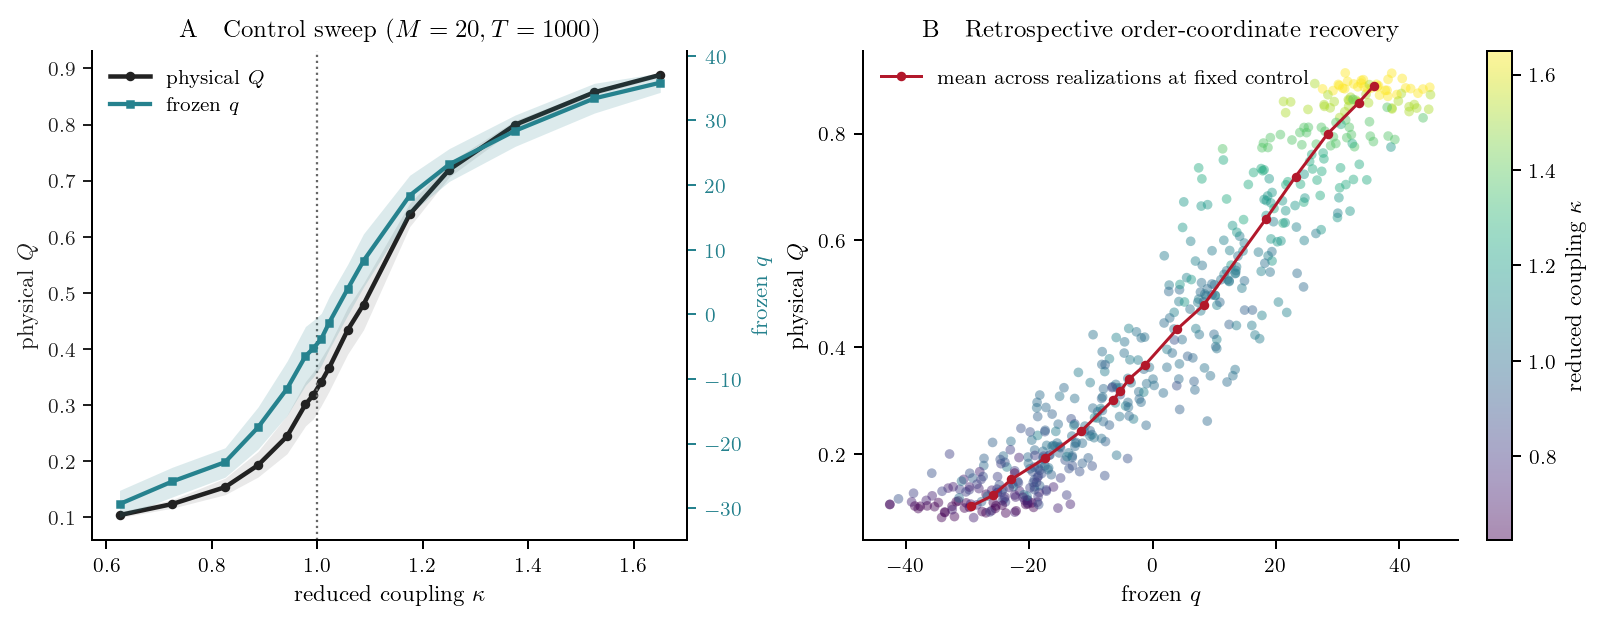

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(8.8, 3.35), constrained_layout=True)
dual_tracking(
    axes[0], kuramoto, control="kappa", Q="Q", q="q", q_sign=-1,
    q_color=COLORS[20], boundary=1.0, title=r"A\quad Control sweep ($M=20,T=1000$)",
)
points = recovery_scatter(
    axes[1], kuramoto, Q="Q", q="q", control="kappa", q_sign=-1,
    title=r"B\quad Retrospective order-coordinate recovery",
)
fig.colorbar(points, ax=axes[1], label=r"reduced coupling $\kappa$")
# fig.savefig(FIGURE_DIR / "kuramoto_headline.svg")
plt.show()

# 2. Stuart--Landau population

### Governing equation

\[
\dot z_j=\left(1-|z_j|^2+i\omega_j\right)z_j+K(Z-z_j),
\qquad Z=\frac1N\sum_{j=1}^{N}z_j,
\qquad R=|Z|.
\]

The canonical collective quantity is $Q=\langle R\rangle_t$. It measures the amplitude of the population mean field: large $Q$ indicates collective locking, small $Q$ incoherence, while $R(t)$'s variability distinguishes steady locking from unsteady collective motion.

**Phase diagram and control.** Matthews and Strogatz derive and simulate a genuine $(K,\gamma)$ phase diagram containing locking, incoherence, amplitude death and an intervening unsteady region. The published diagram is Fig. 2(a), and the exact $K=0.8$ intercept is illustrated in their Fig. 1 at $\gamma=0.6,0.8,1.0,1.2$. Verified source: [APS article](https://doi.org/10.1103/PhysRevLett.65.1701) and [author-hosted PDF](https://static1.squarespace.com/static/5436e695e4b07f1e91b30155/t/54e2603ce4b034409bcebb7d/1424121916823/phase-diagram-for-the-collective-behavior-of-limit-cycle-oscillators.pdf). We fix $K=0.8$ and sweep $\gamma=0.55$ to $1.25$.

**Observation and $q$.** The primary arm is genuinely full observation, $M=N=8,16,32$, with $T=100,500,1000$. One common target-blind development transform is frozen and applied to the interleaved confirmation controls. The joint full/partial bank failed its strict missingness gate, but all 648 full-observation rows passed; the result below is therefore an arm-specific confirmation.

**Performance.** At confirmation, overall $\rho=0.748$, within-$\gamma$ $\rho=0.331$, and control-cell-mean $\rho=1.0$. Analytic phase coherence is stronger ($\rho=0.930$); supervised q-readout MAE $0.0407$ is worse than control-only MAE $0.0334$.

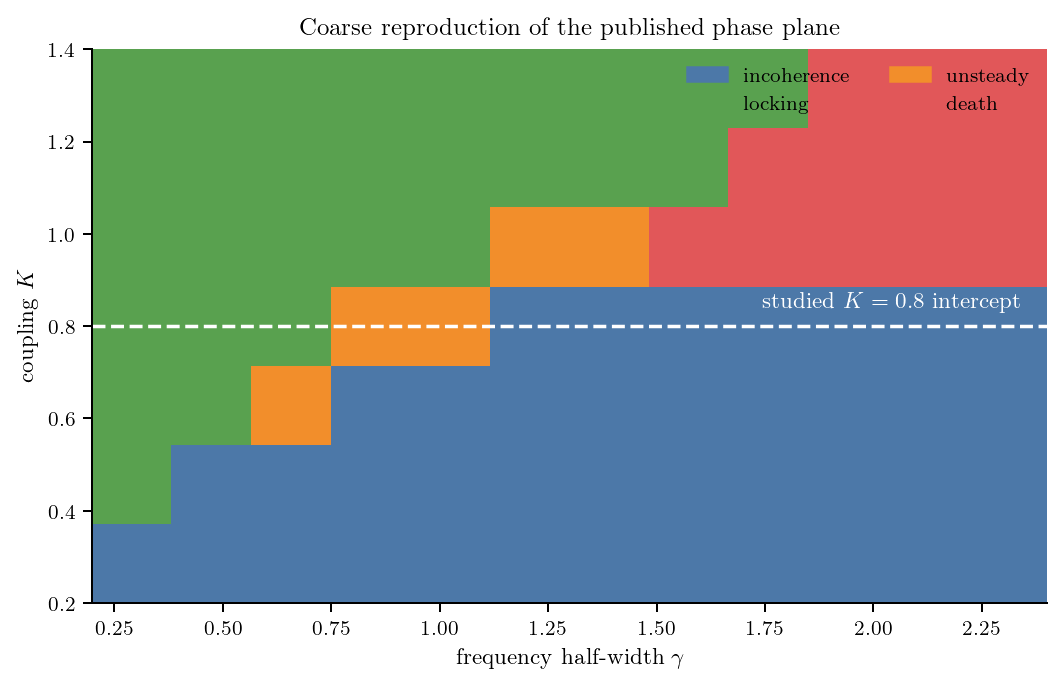

This colour classification is a repository physics diagnostic, not a replacement for the analytical boundaries in Fig. 2(a) of the paper.


In [4]:
fig, ax = plt.subplots(figsize=(5.8, 3.7), constrained_layout=True)
phase_names = [sl_plane_summary["phase_codes"][str(i)] for i in range(4)]
phase_colors = ["#4c78a8", "#59a14f", "#f28e2b", "#e15759"]
extent = [
    sl_plane["grid_frequency_half_widths"].min(),
    sl_plane["grid_frequency_half_widths"].max(),
    sl_plane["grid_couplings"].min(),
    sl_plane["grid_couplings"].max(),
]
ax.imshow(sl_plane["phase_code_grid"], origin="lower", aspect="auto", extent=extent, interpolation="nearest", cmap=ListedColormap(phase_colors), vmin=-.5, vmax=3.5)
ax.axhline(.8, color="white", lw=1.4, ls="--")
ax.text(2.34, .83, r"studied $K=0.8$ intercept", color="white", ha="right", va="bottom")
ax.set(xlabel=r"frequency half-width $\gamma$", ylabel=r"coupling $K$", title="Coarse reproduction of the published phase plane")
ax.legend(handles=[Patch(color=color, label=name) for color, name in zip(phase_colors, phase_names, strict=True)], frameon=False, ncol=2, loc="upper right")
paper_axis(ax)
# fig.savefig(FIGURE_DIR / "stuart_landau_phase_plane.svg")
plt.show()
print("This colour classification is a repository physics diagnostic, not a replacement for the analytical boundaries in Fig. 2(a) of the paper.")

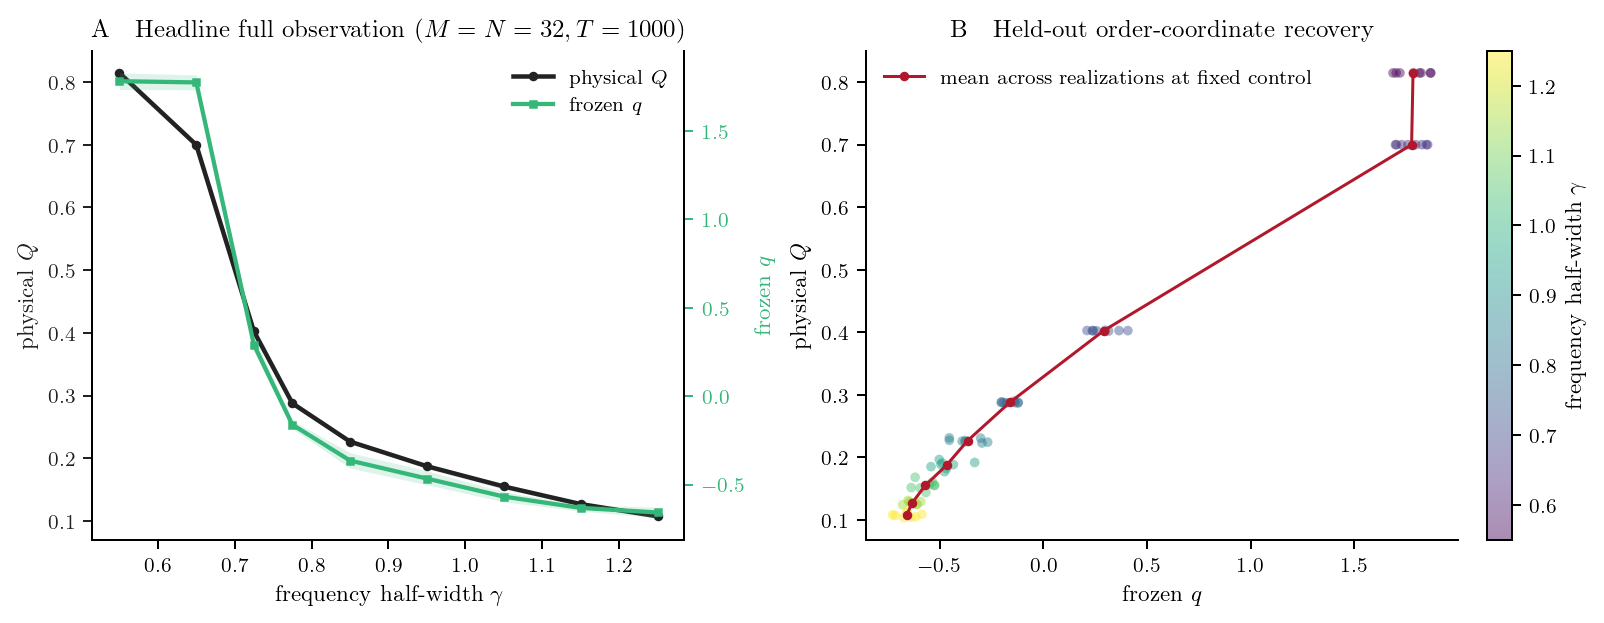

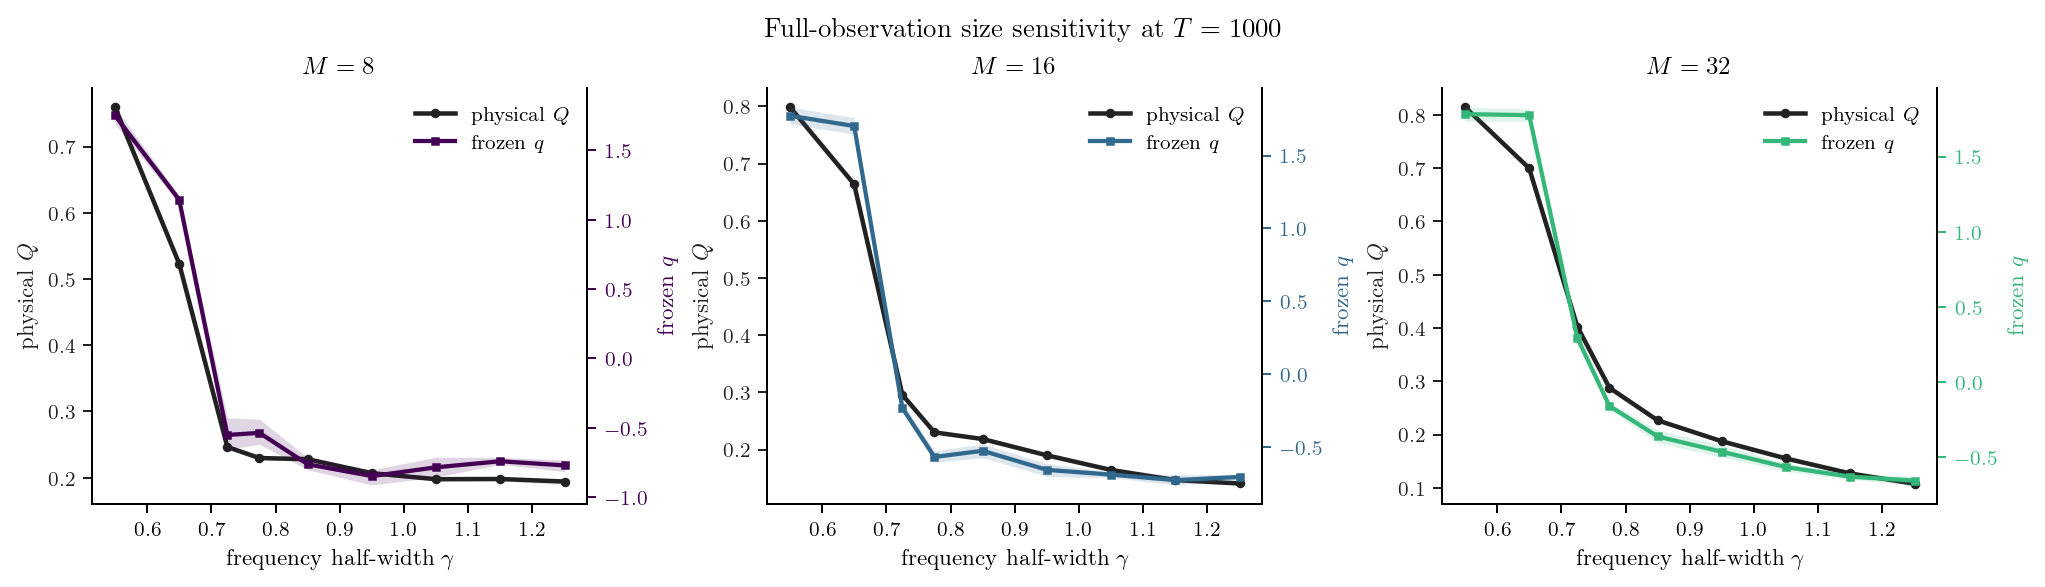

In [5]:
sl_headline = sl_primary.query("M == 32")
fig, axes = plt.subplots(1, 2, figsize=(8.8, 3.35), constrained_layout=True)
dual_tracking(
    axes[0], sl_headline, control="gamma", Q="Q_R_mean", q="q", q_sign=1,
    q_color=COLORS[32], title=r"A\quad Headline full observation ($M=N=32,T=1000$)",
)
points = recovery_scatter(
    axes[1], sl_headline, Q="Q_R_mean", q="q", control="gamma", q_sign=1,
    title=r"B\quad Held-out order-coordinate recovery",
)
fig.colorbar(points, ax=axes[1], label=r"frequency half-width $\gamma$")
# fig.savefig(FIGURE_DIR / "stuart_landau_headline.svg")
plt.show()

fig = size_tracking(
    sl_primary, control="gamma", Q="Q_R_mean", q="q", q_sign=1,
    boundary=None, title=r"Full-observation size sensitivity at $T=1000$",
)
# fig.savefig(FIGURE_DIR / "stuart_landau_by_M.svg")
plt.show()

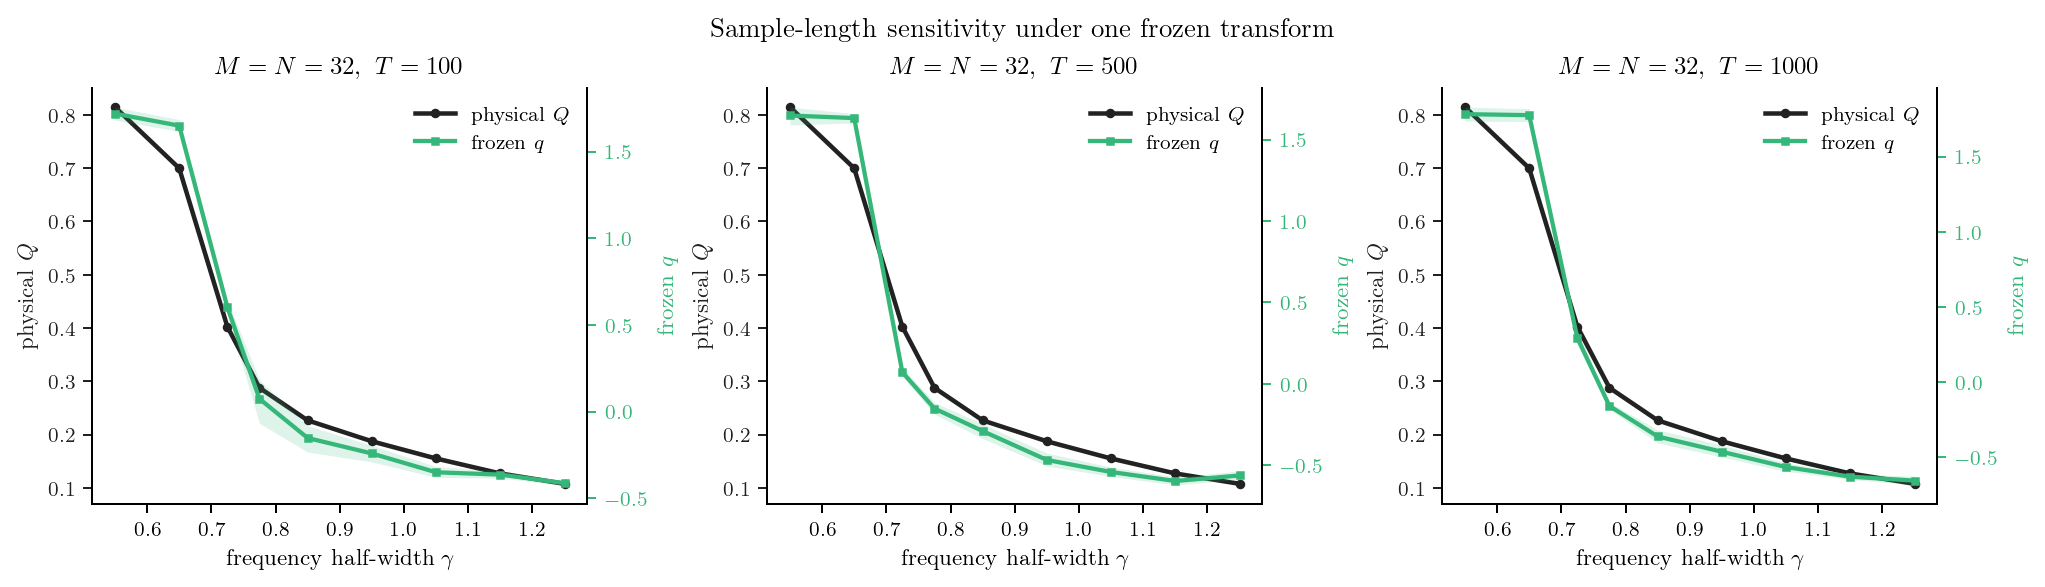

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(11.25, 3.15), constrained_layout=True)
for ax, T in zip(axes, [100, 500, 1000], strict=True):
    dual_tracking(
        ax, sl.query("M == 32 and T == @T"), control="gamma", Q="Q_R_mean",
        q="q", q_sign=1, q_color=COLORS[32], title=rf"$M=N=32,\ T={T}$",
    )
fig.suptitle(r"Sample-length sensitivity under one frozen transform")
# fig.savefig(FIGURE_DIR / "stuart_landau_by_T_M32.svg")
plt.show()

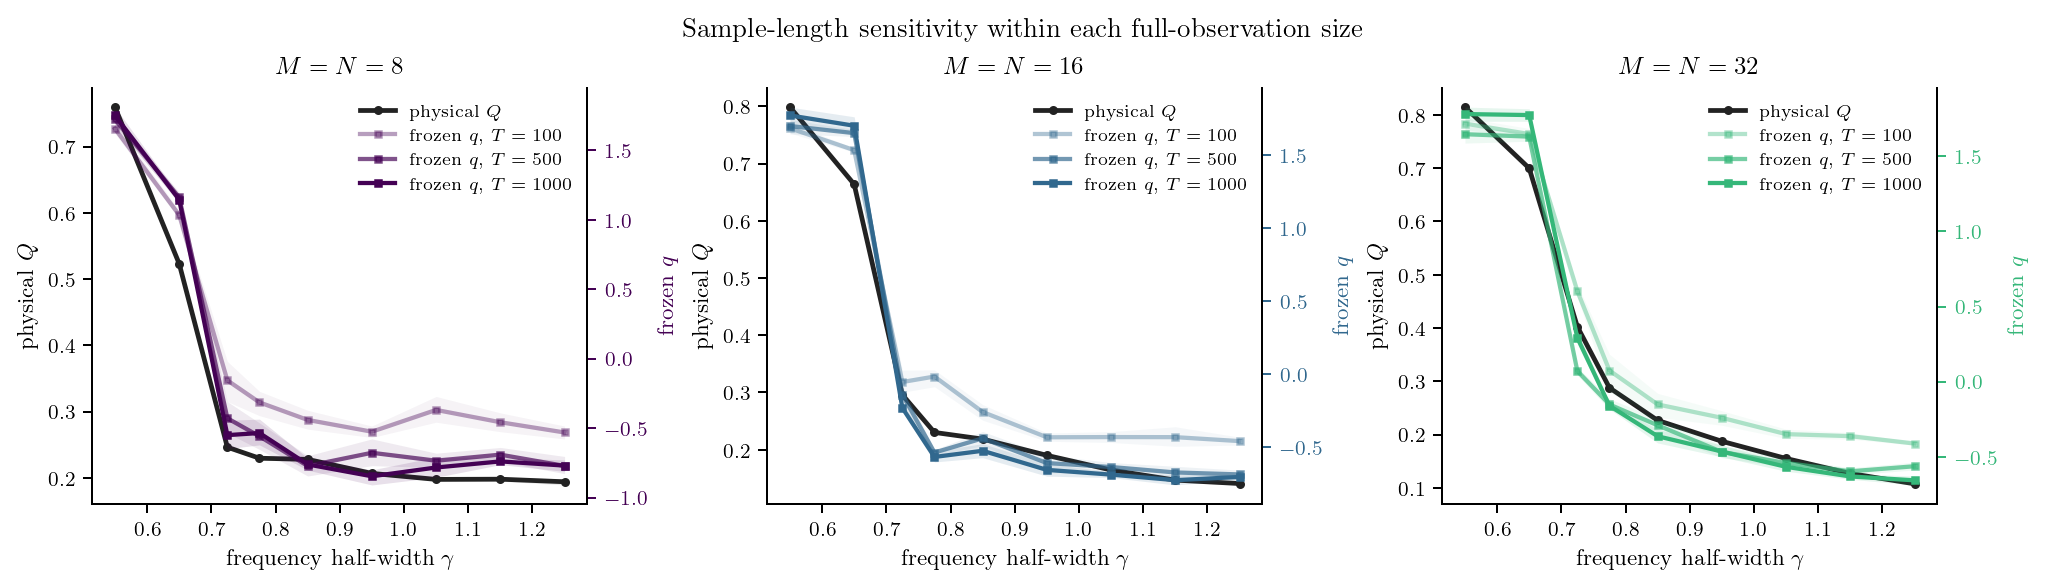

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(11.25, 3.15), constrained_layout=True)
T_ALPHA = {100: .38, 500: .68, 1000: 1.0}
for ax, M in zip(axes, [8, 16, 32], strict=True):
    q_axis = ax.twinx()
    physical = bootstrap_curve(sl.query("M == @M and T == 1000"), "gamma", "Q_R_mean", seed=7211 + M)
    line_Q, = ax.plot(physical.gamma, physical["mean"], color=Q_COLOR, lw=1.9, marker="o", ms=2.6, label=r"physical $Q$")
    ax.fill_between(physical.gamma, physical.lower, physical.upper, color=Q_FILL, alpha=.16, linewidth=0)
    lines = [line_Q]
    for T in [100, 500, 1000]:
        learned = bootstrap_curve(sl.query("M == @M and T == @T"), "gamma", "q", seed=8111 + M + T)
        line_q, = q_axis.plot(
            learned.gamma, learned["mean"], color=COLORS[M], alpha=T_ALPHA[T],
            lw=1.7, marker="s", ms=2.4, label=rf"frozen $q$, $T={T}$",
        )
        q_axis.fill_between(
            learned.gamma, learned.lower, learned.upper,
            color=COLORS[M], alpha=.12 * T_ALPHA[T], linewidth=0,
        )
        lines.append(line_q)
    ax.set(xlabel=CONTROL_LABELS["gamma"], ylabel=r"physical $Q$", title=rf"$M=N={M}$")
    q_axis.set_ylabel(r"frozen $q$", color=COLORS[M])
    q_axis.tick_params(axis="y", colors=COLORS[M])
    paper_axis(ax)
    paper_axis(q_axis, right=True)
    ax.legend(lines, [line.get_label() for line in lines], frameon=False, fontsize=7, loc="best")
fig.suptitle(r"Sample-length sensitivity within each full-observation size")
# fig.savefig(FIGURE_DIR / "stuart_landau_T_lines_by_M.svg")
plt.show()

### Fine locking-to-unsteady boundary confirmation

The broad sweep above tests recovery across several collective regimes. This independent test asks the narrower question motivating the present study: can the already-frozen target-blind coordinate resolve one documented local boundary?

We retain the published $K=0.8$ intercept and finely sweep $\gamma=0.680,0.685,\ldots,0.770$ using eight new matched seeds, full observation $M=N=32$, and $T=1000$. No representation component, feature mask, scaling choice or sign is refitted on these rows. A prior physics-only finite-size scout located the steepest $\langle R\rangle$ interval at $0.72$--$0.73$ for $N=32$, $0.73$--$0.74$ for $N=64$, and $0.74$--$0.75$ for both $N=128$ and $N=800$. Thus any $N=32$ displacement is an expected finite-size effect, not a portable thermodynamic critical value.

The primary physical quantity remains $Q=\langle R\rangle_t$. The temporal standard deviation $\operatorname{sd}_t(R)$ is shown only as a boundary-sensitive diagnostic: it distinguishes steady locking from the onset of unsteady collective motion and is not substituted for the canonical mean-field amplitude.

**Held-out result.** All eligibility gates passed and all 152 rows were retained. The frozen $q$ tracks $\langle R\rangle$ with $\rho=0.886$ (95% CI $[0.882,0.893]$); the correlation of realization means across $\gamma$ is $0.896$. Most importantly, the steepest interval is exactly $\gamma=0.720$--$0.725$ for $q$, $\langle R\rangle$, and $\operatorname{sd}_t(R)$. The latter rises as coherence falls, hence $\rho(q,\operatorname{sd}_t(R))=-0.933$. Within fixed $\gamma$, $q$ does not recover realization-level $Q$ fluctuations ($\rho=-0.220$), so this supports macroscopic transition tracking and localization, not microscopic state estimation. Analytic phase coherence is slightly stronger overall ($\rho=0.915$).

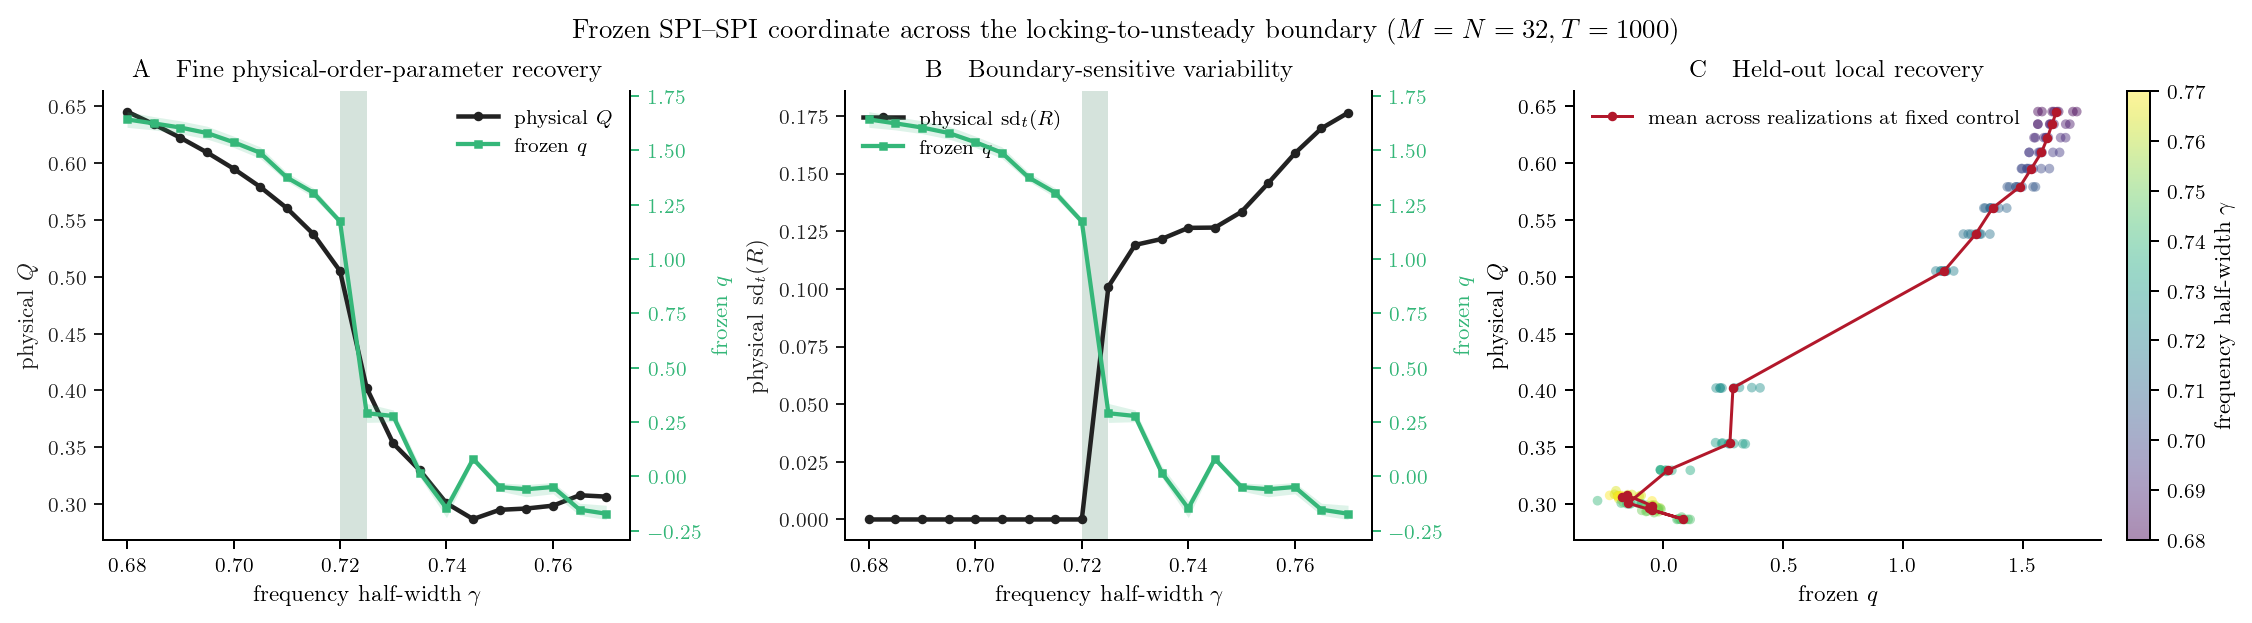

,"overall rho(q, mean R)",within-gamma rho,gamma-mean rho,"rho(q, sd R)",q steepest interval,mean R steepest interval,sd R steepest interval
0,0.886,-0.2196,0.8965,-0.9326,"(0.72, 0.725)","(0.72, 0.725)","(0.72, 0.725)"


In [8]:
localization = sl_fine_summary["fine_boundary_localization"]
q_interval = localization["q"]["interval"]
Q_interval = localization["Q_R_mean"]["interval"]
Q_sd_interval = localization["Q_R_sd"]["interval"]

fig, axes = plt.subplots(1, 3, figsize=(12.4, 3.35), constrained_layout=True)
dual_tracking(
    axes[0], sl_fine, control="gamma", Q="Q_R_mean", q="q", q_sign=1,
    q_color=COLORS[32], title=r"A\quad Fine physical-order-parameter recovery",
)
axes[0].axvspan(*Q_interval, color=Q_COLOR, alpha=.10, linewidth=0)
axes[0].axvspan(*q_interval, color=COLORS[32], alpha=.10, linewidth=0)

dual_tracking(
    axes[1], sl_fine, control="gamma", Q="Q_R_sd", q="q", q_sign=1,
    q_color=COLORS[32], title=r"B\quad Boundary-sensitive variability",
    Q_label=r"physical $\mathrm{sd}_t(R)$",
)
axes[1].set_ylabel(r"physical $\mathrm{sd}_t(R)$")
axes[1].axvspan(*Q_sd_interval, color=Q_COLOR, alpha=.10, linewidth=0)
axes[1].axvspan(*q_interval, color=COLORS[32], alpha=.10, linewidth=0)

points = recovery_scatter(
    axes[2], sl_fine, Q="Q_R_mean", q="q", control="gamma", q_sign=1,
    title=r"C\quad Held-out local recovery",
)
fig.colorbar(points, ax=axes[2], label=r"frequency half-width $\gamma$")
fig.suptitle(r"Frozen SPI--SPI coordinate across the locking-to-unsteady boundary ($M=N=32,T=1000$)")
# fig.savefig(FIGURE_DIR / "stuart_landau_fine_boundary.svg")
plt.show()

fine_metrics = pd.DataFrame([
    {
        "overall rho(q, mean R)": sl_fine_summary["full_association"]["overall_spearman"],
        "within-gamma rho": sl_fine_summary["full_association"]["within_gamma_spearman"],
        "gamma-mean rho": sl_fine_summary["full_pooled_gamma_mean_spearman"],
        "rho(q, sd R)": sl_fine_summary["full_R_sd_association"]["overall_spearman"],
        "q steepest interval": tuple(q_interval),
        "mean R steepest interval": tuple(Q_interval),
        "sd R steepest interval": tuple(Q_sd_interval),
    }
])
display(fine_metrics.round(4))

# 3. Miller--Huse chaotic coupled-map lattice

### Governing equation

\[
x_{ij}(t+1)=(1-4g)f_\mu(x_{ij}(t))
+g\sum_{(k,l)\in\mathrm{nn}(i,j)}f_\mu(x_{kl}(t)),
\]

with synchronous updates, periodic boundaries and the original odd piecewise-linear map

\[
f_\mu(x)=
\begin{cases}
-\frac{2\mu}{3}-\mu x, & -1\le x\le-\frac13,\\
\mu x, & |x|\le\frac13,\\
\frac{2\mu}{3}-\mu x, & \frac13\le x\le1,
\end{cases}
\qquad \mu=3.
\]

The canonical finite-size order parameter is

\[
Q_{\mathrm{MH}}=\left\langle\left|\frac1{L^2}\sum_{ij}\operatorname{sign}(x_{ij})\right|\right\rangle_t.
\]

It is the absolute Ising-like magnetization of the emergent sign field. The absolute value prevents finite-size sign reversals from averaging an ordered state to zero.

**Phase transition and control.** Increasing nearest-neighbour coupling $g$ produces a continuous disordered-to-ferromagnetically ordered transition. We sweep $g=0.18$ to $0.23$, densely around the refined $g_c=0.20534(2)$. This is a one-control transition curve, not a two-control phase plane. Sources: [Miller & Huse 1993](https://doi.org/10.1103/PhysRevE.48.2528) and the refined synchronous-update study [Marcq, Chaté & Manneville 1997](https://doi.org/10.1103/PhysRevE.55.2606). The latter cautions against treating two-dimensional Ising universality as settled.

**Observation and $q$.** Physics uses $L=128$, hence $N=16{,}384$, while p90 observes nested dispersed $M=8,16,32$ sites with $T=1000$. The global $Q_{\mathrm{MH}}$ comes from a separate two-million-step future. Full $M=N$ p90 is infeasible because each MPI is dense in $M^2$.

**Performance.** The strict confirmation stopped before outcome access because one of 216 rows exceeded 5% selected-feature missingness. The target-blind 215-row sensitivity gives $\rho=0.888$, control-cell-mean $\rho=0.950$, and within-$g$ $\rho=0.015$. Temporal spectral entropy is stronger ($\rho=0.941$); q-readout MAE $0.0744$ is much worse than control-only MAE $0.0136$.

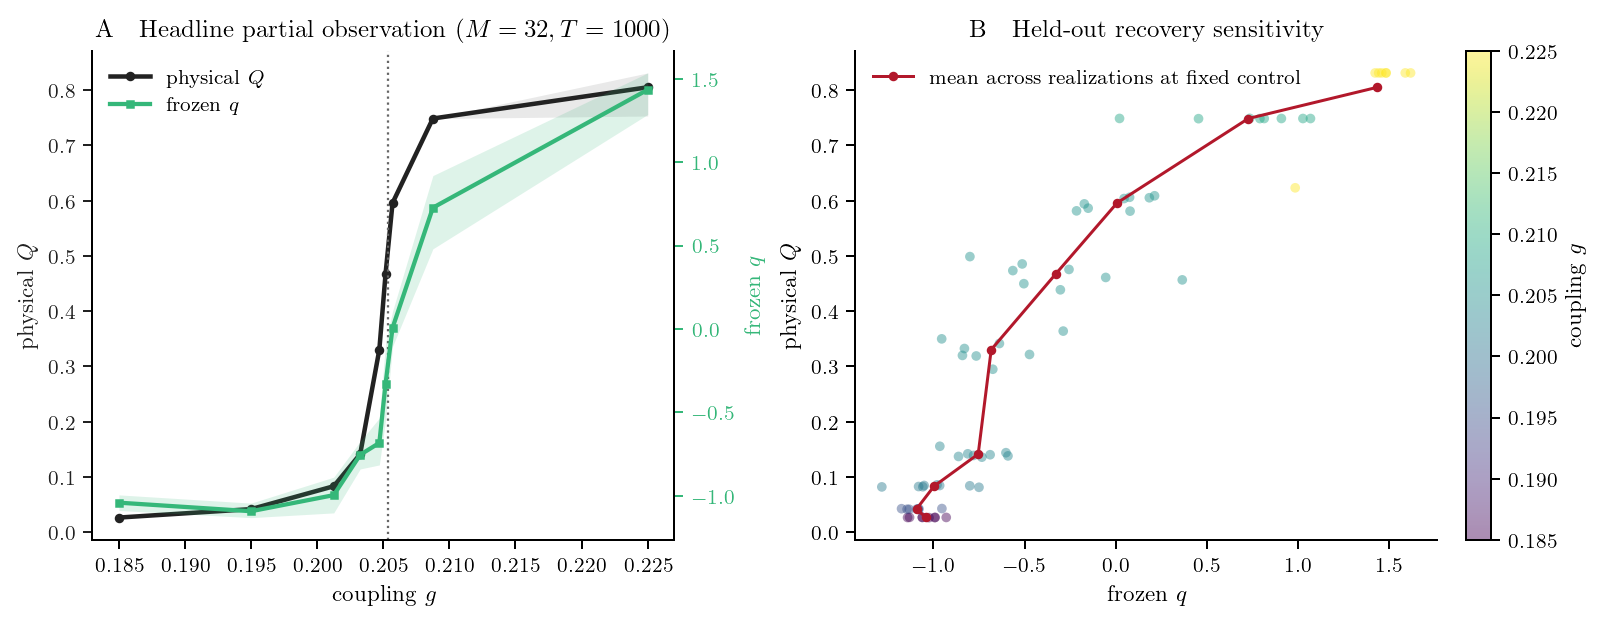

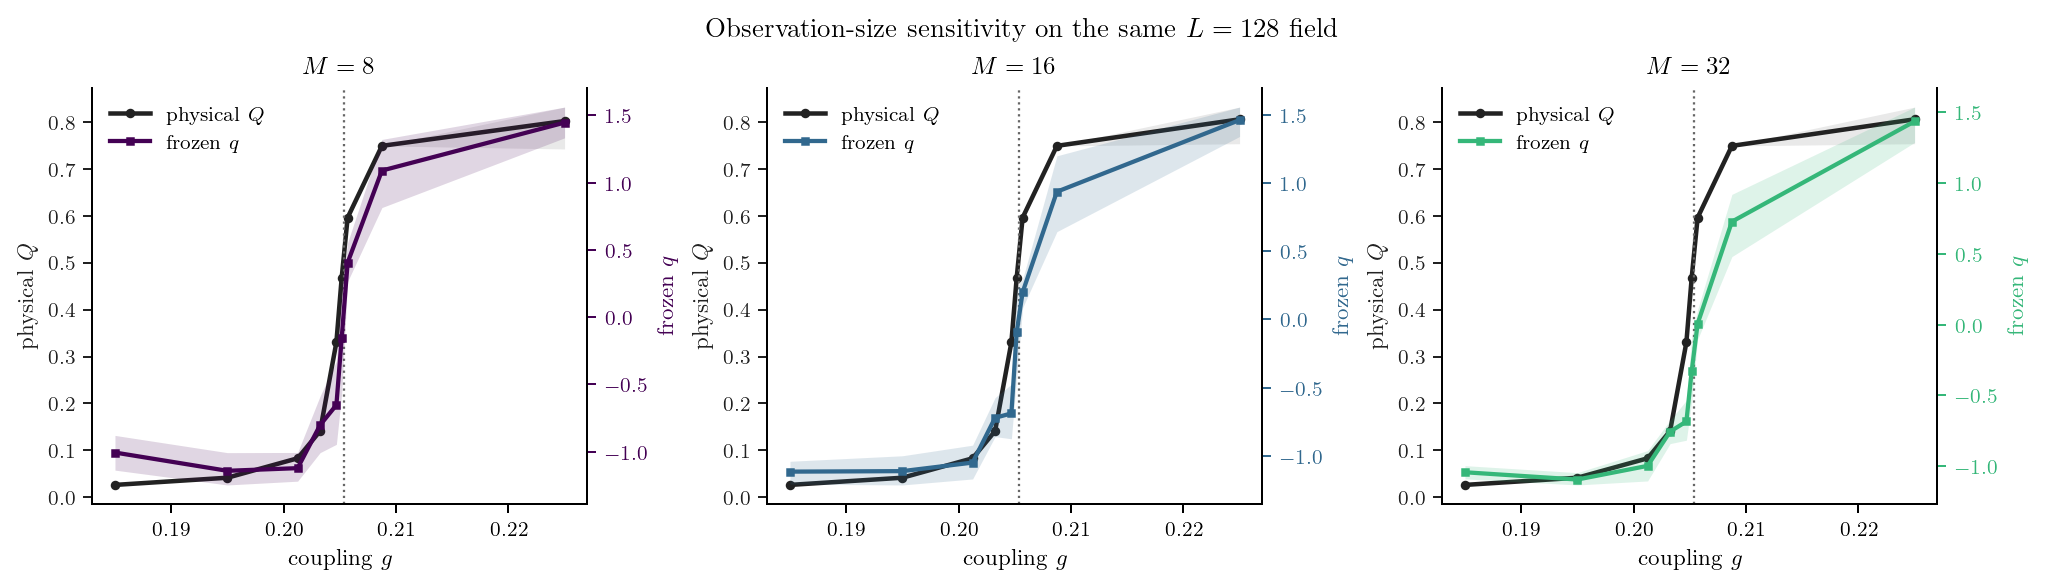

In [9]:
mh_headline = mh.query("M == 32")
fig, axes = plt.subplots(1, 2, figsize=(8.8, 3.35), constrained_layout=True)
dual_tracking(
    axes[0], mh_headline, control="g", Q="Q_spin_abs", q="q", q_sign=1,
    q_color=COLORS[32], boundary=.20534,
    title=r"A\quad Headline partial observation ($M=32,T=1000$)",
)
points = recovery_scatter(
    axes[1], mh_headline, Q="Q_spin_abs", q="q", control="g", q_sign=1,
    title=r"B\quad Held-out recovery sensitivity",
)
fig.colorbar(points, ax=axes[1], label=r"coupling $g$")
# fig.savefig(FIGURE_DIR / "miller_huse_headline.svg")
plt.show()

fig = size_tracking(
    mh, control="g", Q="Q_spin_abs", q="q", q_sign=1,
    boundary=.20534, title=r"Observation-size sensitivity on the same $L=128$ field",
)
# fig.savefig(FIGURE_DIR / "miller_huse_by_M.svg")
plt.show()

# 4. Quadratic/Kaneko coupled-map lattice

### Governing equation

\[
x_i(t+1)=(1-\epsilon)f_\alpha(x_i(t))
+\frac{\epsilon}{2}\left[f_\alpha(x_{i-1}(t))+f_\alpha(x_{i+1}(t))\right],
\qquad f_\alpha(x)=1-\alpha x^2.
\]

**Critical qualification:** there is no single accepted canonical scalar $Q$ spanning this path. We therefore predeclared a physical diagnostic vector

\[
\mathbf Q=(H_{\rm temporal},\ H_{\rm pattern},\ P_{[0.25,0.45]\pi},\ A_{\rm period\,2}),
\]

and use $Q_{\rm phys,1}$, the first development-fitted PC of its standardized components, only as an evaluative regime coordinate. It explains 95.2% of the vector's variance on this intercept, but it is not a universal order parameter.

**Phase structure and control.** We fix $\epsilon=0.3$ and sweep $\alpha=1.60$ to $2.00$. Long physics runs identify low-entropy patterned dynamics through about $\alpha=1.73$, seed-dependent coexistence around $1.74$--$1.76$, and high-entropy dynamics by $1.77$. Kaneko's paper documents qualitative pattern-selection, defect/intermittency and fully developed spatiotemporal-chaos regions and introduces several quantifiers, but its diagram is not a unique numerically portable phase boundary: topology, coupling convention, size, burn-in and initial basin matter. Verified source: [Kaneko 1989](https://doi.org/10.1016/0167-2789(89)90227-3). The exact-model long-transient warning is supported by [Loskutov, Prokhorov & Rybalko](https://chaos.phys.msu.ru/loskutov/PDF/TMPh_quadratic_cml.PDF).

**Observation and $q$.** Primary physics uses $N=512$, observed at $M=8,16,32$, $T=1000$. The target-blind q-space uses its first two PCs for vector-geometry comparisons; $q_1$ is shown below with an outcome-informed sign flip for display only. Separate $M=N=8,16,32$ runs are finite-size diagnostics.

**Performance.** $q_1$ versus $Q_{\rm phys,1}$ has $|\rho|=0.733$; two-dimensional distance recovery is $\rho=0.667$ overall and negative within fixed $\alpha$. Mean absolute correlation and temporal spectral entropy are much stronger ($|\rho|=0.931,0.950$). This is a negative/limitation result, not a canonical recovery claim.

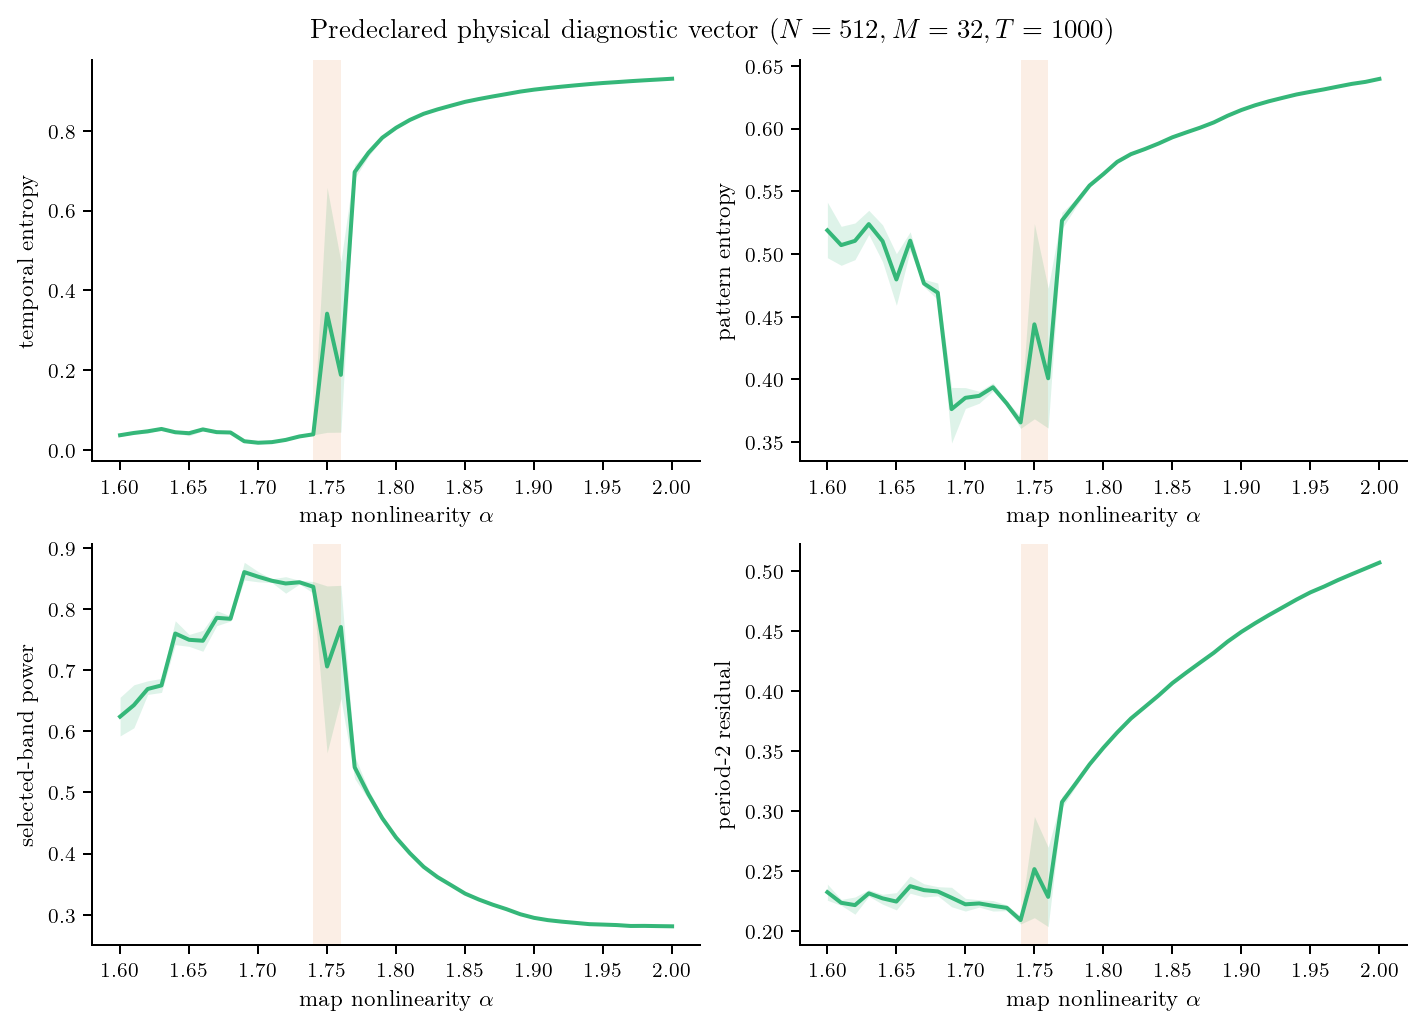

In [10]:
component_labels = {
    "Q_temporal_entropy": r"temporal entropy",
    "Q_pattern_entropy": r"pattern entropy",
    "Q_selected_band_power": r"selected-band power",
    "Q_period2_residual": r"period-2 residual",
}
fig, axes = plt.subplots(2, 2, figsize=(7.8, 5.6), constrained_layout=True)
for ax, (column, label) in zip(axes.flat, component_labels.items(), strict=True):
    curve = bootstrap_curve(cml_held.query("M == 32"), "alpha", column, bootstraps=2000, seed=4111)
    ax.plot(curve.alpha, curve["mean"], color=COLORS[32], lw=1.6)
    ax.fill_between(curve.alpha, curve.lower, curve.upper, color=COLORS[32], alpha=.16, linewidth=0)
    ax.axvspan(1.74, 1.76, color="#d95f02", alpha=.10, linewidth=0)
    ax.set(xlabel=r"map nonlinearity $\alpha$", ylabel=label)
    paper_axis(ax)
fig.suptitle(r"Predeclared physical diagnostic vector ($N=512,M=32,T=1000$)")
# fig.savefig(FIGURE_DIR / "quadratic_cml_physical_vector.svg")
plt.show()

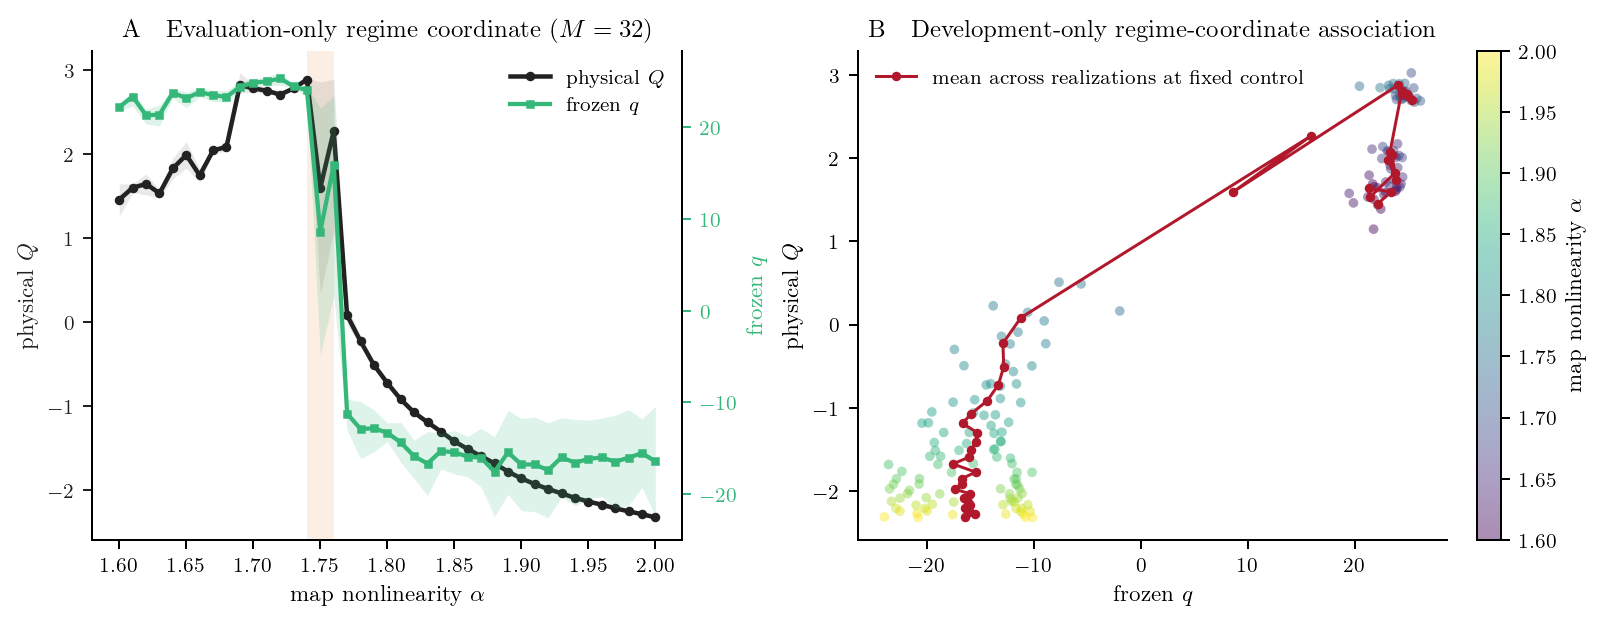

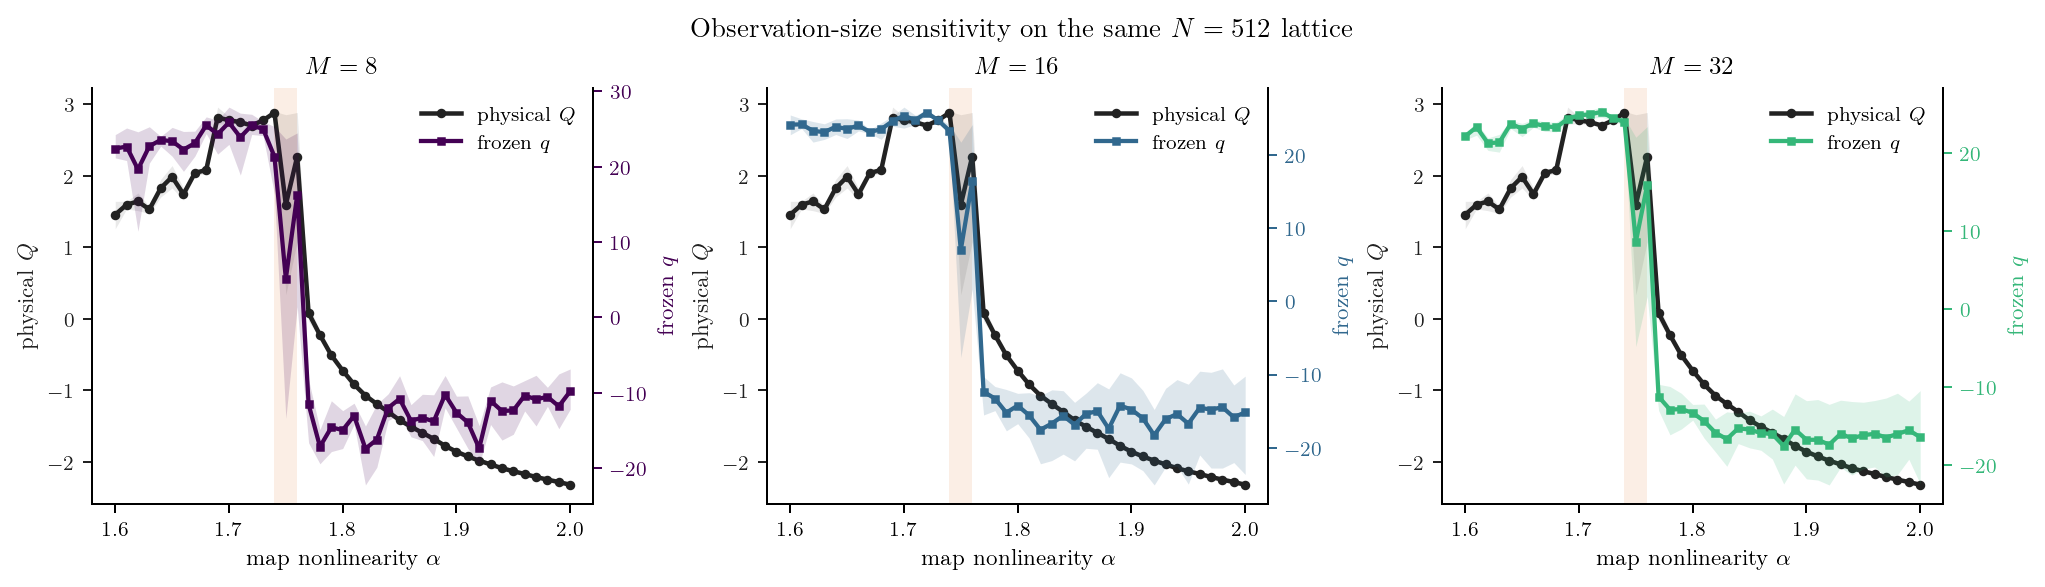

In [11]:
cml_headline = cml_held.query("M == 32")
fig, axes = plt.subplots(1, 2, figsize=(8.8, 3.35), constrained_layout=True)
dual_tracking(
    axes[0], cml_headline, control="alpha", Q="Q_phys1", q="q1", q_sign=-1,
    q_color=COLORS[32], boundary=None,
    title=r"A\quad Evaluation-only regime coordinate ($M=32$)",
)
axes[0].axvspan(1.74, 1.76, color="#d95f02", alpha=.10, linewidth=0)
points = recovery_scatter(
    axes[1], cml_headline, Q="Q_phys1", q="q1", control="alpha", q_sign=-1,
    title=r"B\quad Development-only regime-coordinate association",
)
fig.colorbar(points, ax=axes[1], label=r"map nonlinearity $\alpha$")
# fig.savefig(FIGURE_DIR / "quadratic_cml_headline.svg")
plt.show()

fig = size_tracking(
    cml_held, control="alpha", Q="Q_phys1", q="q1", q_sign=-1,
    boundary=None, title=r"Observation-size sensitivity on the same $N=512$ lattice",
)
for ax in fig.axes[:3]:
    ax.axvspan(1.74, 1.76, color="#d95f02", alpha=.10, linewidth=0)
# fig.savefig(FIGURE_DIR / "quadratic_cml_by_M.svg")
plt.show()

# Comparative interpretation

Spearman correlation is the primary recovery metric because $q$'s scale is arbitrary and the scientific question is whether it orders dynamical regimes consistently. Cell-mean correlation isolates the macroscopic sweep. Within-control correlation is stricter: it tests whether $q$ captures realization-level fluctuations after the control trend is removed. MAE belongs only to a separately supervised decoder and should not be described as unsupervised discovery.

The decisive limitation is common across the benchmarks: a target-blind SPI--SPI coordinate can track a changing physical order parameter, but simple task-specific observables often track it better, and knowing the control parameter can predict $Q$ more accurately. The contribution is a common, system-agnostic representation—not universal optimality.

In [12]:
cml_means = cml_held.groupby("alpha")[["q1", "Q_phys1"]].mean()
comparison = pd.DataFrame([
    {
        "system": "Kuramoto",
        "evidence": "retrospective full-catalogue baseline",
        "overall |rho|": abs(kuramoto_summary["primary_association"]["overall_spearman"]),
        "within-control |rho|": abs(kuramoto_summary["primary_association"]["within_kappa_spearman"]),
        "cell-mean |rho|": abs(spearman(kuramoto.groupby("kappa").q.mean(), kuramoto.groupby("kappa").Q.mean())),
        "q decoder MAE": kuramoto_summary["supervised_isotonic_readout"]["mae"],
        "control-only MAE": np.nan,
        "strongest simple |rho|": max(abs(v["overall_spearman"]) for v in kuramoto_summary["baseline_associations"].values()),
    },
    {
        "system": "Stuart--Landau",
        "evidence": "full-observation arm-specific confirmation",
        "overall |rho|": abs(sl_summary["full_association"]["overall_spearman"]),
        "within-control |rho|": abs(sl_summary["full_association"]["within_gamma_spearman"]),
        "cell-mean |rho|": abs(sl_summary["full_pooled_gamma_mean_spearman"]),
        "q decoder MAE": sl_summary["supervised_q_readout"]["mae"],
        "control-only MAE": sl_summary["control_only_readout"]["mae"],
        "strongest simple |rho|": max(abs(v["overall_spearman"]) for v in sl_summary["input_baselines"].values()),
    },
    {
        "system": "Stuart--Landau fine boundary",
        "evidence": "independent frozen-coordinate confirmation",
        "overall |rho|": abs(sl_fine_summary["full_association"]["overall_spearman"]),
        "within-control |rho|": abs(sl_fine_summary["full_association"]["within_gamma_spearman"]),
        "cell-mean |rho|": abs(sl_fine_summary["full_pooled_gamma_mean_spearman"]),
        "q decoder MAE": sl_fine_summary["supervised_q_readout"]["mae"],
        "control-only MAE": sl_fine_summary["control_only_readout"]["mae"],
        "strongest simple |rho|": max(abs(v["overall_spearman"]) for v in sl_fine_summary["input_baselines"].values()),
    },
    {
        "system": "Miller--Huse",
        "evidence": "one-row-exclusion confirmation sensitivity",
        "overall |rho|": abs(mh_summary["association"]["overall_spearman"]),
        "within-control |rho|": abs(mh_summary["association"]["within_gamma_spearman"]),
        "cell-mean |rho|": abs(mh_summary["pooled_g_mean_spearman"]),
        "q decoder MAE": mh_summary["supervised_q_readout"]["mae"],
        "control-only MAE": mh_summary["control_only_readout"]["mae"],
        "strongest simple |rho|": max(abs(v["overall_spearman"]) for v in mh_summary["input_baselines"].values()),
    },
    {
        "system": "Quadratic CML",
        "evidence": "development-only noncanonical stress test",
        "overall |rho|": abs(cml_summary["held_large_q1_vs_physical_pc1"]["overall_spearman"]),
        "within-control |rho|": abs(cml_summary["held_large_q1_vs_physical_pc1"]["within_alpha_spearman"]),
        "cell-mean |rho|": abs(spearman(cml_means.q1, cml_means.Q_phys1)),
        "q decoder MAE": cml_summary["held_large_supervised_vector_mae"],
        "control-only MAE": cml_summary["held_large_control_only_vector_mae"],
        "strongest simple |rho|": max(abs(v["overall_spearman"]) for v in cml_summary["held_large_input_baseline_associations_with_physical_pc1"].values()),
    },
])
display(comparison.round(3))

,system,evidence,overall |rho|,within-control |rho|,cell-mean |rho|,q decoder MAE,control-only MAE,strongest simple |rho|
0,Kuramoto,retrospective full-catalogue baseline,0.956,0.628,1.000,0.059,NaN,0.975
1,Stuart--Landau,full-observation arm-specific confirmation,0.748,0.331,1.000,0.041,0.033,0.930
2,Stuart--Landau fine boundary,independent frozen-coordinate confirmation,0.886,0.220,0.896,0.031,0.086,0.915
3,Miller--Huse,one-row-exclusion confirmation sensitivity,0.888,0.015,0.950,0.074,0.014,0.941
4,Quadratic CML,development-only noncanonical stress test,0.733,0.155,0.756,0.152,0.063,0.950
